# Swin-Tiny Fine-Tuning Strategies on BloodMNIST

This notebook runs three additional fine-tuning strategies for `swin_tiny_patch4_window7_224`:

- `feature_extraction`
- `gradual_unfreezing`
- `discriminative_learning_rates`

It saves report-friendly artifacts under:

- `checkpoints/`
- `results/`
- `figures/`


In [1]:
from pathlib import Path
import csv
import json

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

project_root = Path('.')
script_path = project_root / 'run_swin_strategies.py'
print(f'Using script: {script_path.resolve()}')


Using script: F:\课程文档\Term2\DSS5104\Assignment2\run_swin_strategies.py


In [2]:
%run ./run_swin_strategies.py --strategies feature_extraction gradual_unfreezing discriminative_learning_rates


f:\课程文档\Term2\DSS5104\Assignment2\ml\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda
Running strategies: ['feature_extraction', 'gradual_unfreezing', 'discriminative_learning_rates']
Train fraction: 100%
Epochs: 12
Patience: 3

=== Running feature_extraction ===
[feature_extraction] Epoch 01/12 | Stage: full_model | Train Loss: 1.5853 | Train Acc: 0.509 | Val Loss: 1.2574 | Val Acc: 0.614 | Val F1: 0.483 | Val AUC: 0.930 | Trainable Params: 6,152
[feature_extraction] Epoch 02/12 | Stage: full_model | Train Loss: 1.1748 | Train Acc: 0.652 | Val Loss: 0.9955 | Val Acc: 0.714 | Val F1: 0.652 | Val AUC: 0.950 | Trainable Params: 6,152
[feature_extraction] Epoch 03/12 | Stage: full_model | Train Loss: 0.9934 | Train Acc: 0.709 | Val Loss: 0.8532 | Val Acc: 0.755 | Val F1: 0.710 | Val AUC: 0.961 | Trainable Params: 6,152
[feature_extraction] Epoch 04/12 | Stage: full_model | Train Loss: 0.8853 | Train Acc: 0.741 | Val Loss: 0.7617 | Val Acc: 0.776 | Val F1: 0.736 | Val AUC: 0.967 | Trainable Params: 6,152
[feature_extraction] Epoch 05/12 | Stage: full_mode

In [3]:
summary_path = project_root / 'results' / 'swin_tiny_strategy_summary.csv'
with summary_path.open('r', encoding='utf-8') as handle:
    rows = list(csv.DictReader(handle))

display(Markdown('## Strategy Summary'))
rows


## Strategy Summary

[{'strategy_name': 'feature_extraction',
  'best_epoch': '12',
  'best_val_auc': '0.982562',
  'test_accuracy': '0.831920',
  'test_macro_f1': '0.799439',
  'test_auc': '0.978146',
  'elapsed_seconds': '798.98',
  'trainable_params_at_end': '6152',
  'total_params': '27525506',
  'model_size_mb': '106.06',
  'checkpoint_path': 'checkpoints\\bloodmnist_swin_tiny_feature_extraction_100pct_best.pth'},
 {'strategy_name': 'gradual_unfreezing',
  'best_epoch': '12',
  'best_val_auc': '0.999247',
  'test_accuracy': '0.971061',
  'test_macro_f1': '0.968216',
  'test_auc': '0.998777',
  'elapsed_seconds': '1376.90',
  'trainable_params_at_end': '27525506',
  'total_params': '27525506',
  'model_size_mb': '106.06',
  'checkpoint_path': 'checkpoints\\bloodmnist_swin_tiny_gradual_unfreezing_100pct_best.pth'},
 {'strategy_name': 'discriminative_learning_rates',
  'best_epoch': '6',
  'best_val_auc': '0.998966',
  'test_accuracy': '0.969307',
  'test_macro_f1': '0.966070',
  'test_auc': '0.998392',


In [4]:
json_dir = project_root / 'results'
for json_path in sorted(json_dir.glob('swin_tiny_*_metrics.json')):
    payload = json.loads(json_path.read_text(encoding='utf-8'))
    display(Markdown(f"### {payload['strategy_name']}"))
    print('Best epoch:', payload['best_epoch'])
    print('Checkpoint:', payload['checkpoint_path'])
    print('Test metrics:', payload['test_metrics'])
    print('LR summary:', payload['lr_summary'])
    print()


### discriminative_learning_rates

Best epoch: 6
Checkpoint: checkpoints\bloodmnist_swin_tiny_discriminative_learning_rates_100pct_best.pth
Test metrics: {'loss': 0.12467808165532765, 'accuracy': 0.9693072201110786, 'macro_f1': 0.9660704689031352, 'auc': 0.9983919130841347}
LR summary: [{'group': 'patch_embed', 'lr': 2.5e-05}, {'group': 'layers.0', 'lr': 2.5e-05}, {'group': 'layers.1', 'lr': 5e-05}, {'group': 'layers.2', 'lr': 7.500000000000001e-05}, {'group': 'layers.3', 'lr': 0.0001}, {'group': 'norm', 'lr': 0.0001}, {'group': 'head', 'lr': 0.0002}]



### feature_extraction

Best epoch: 12
Checkpoint: checkpoints\bloodmnist_swin_tiny_feature_extraction_100pct_best.pth
Test metrics: {'loss': 0.5289553218297671, 'accuracy': 0.8319204910844782, 'macro_f1': 0.799438812333564, 'auc': 0.9781463792228233}
LR summary: [{'group': 'trainable_params', 'lr': 0.0001}]



### gradual_unfreezing

Best epoch: 12
Checkpoint: checkpoints\bloodmnist_swin_tiny_gradual_unfreezing_100pct_best.pth
Test metrics: {'loss': 0.09494716447942204, 'accuracy': 0.9710610932475884, 'macro_f1': 0.9682163666789636, 'auc': 0.9987771011860747}
LR summary: [{'group': 'trainable_params', 'lr': 0.0001}]



## bloodmnist_swin_tiny_strategy_training_curves.png

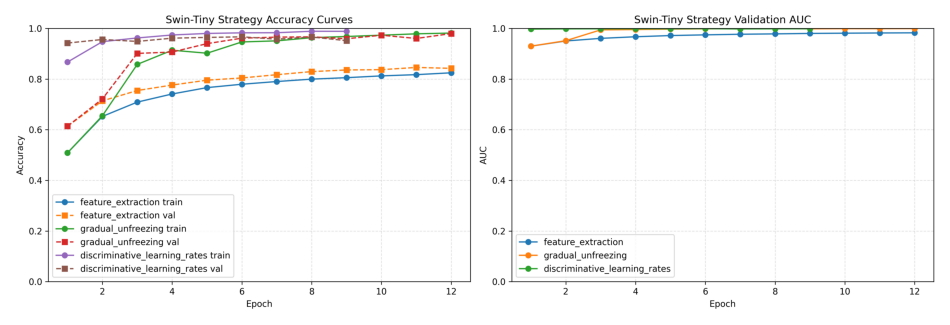

## bloodmnist_swin_tiny_strategy_test_metrics.png

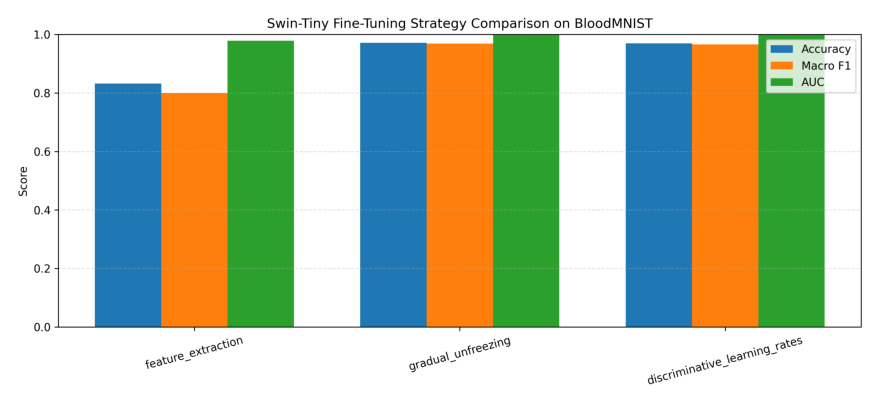

In [5]:
figure_paths = [
    project_root / 'figures' / 'bloodmnist_swin_tiny_strategy_training_curves.png',
    project_root / 'figures' / 'bloodmnist_swin_tiny_strategy_test_metrics.png',
]

for figure_path in figure_paths:
    display(Markdown(f"## {figure_path.name}"))
    image = mpimg.imread(figure_path)
    plt.figure(figsize=(12, 5))
    plt.imshow(image)
    plt.axis('off')
    plt.show()
